In [1]:
import os
import pandas as pd

In [2]:
df = pd.read_csv('./train.csv')
# Print basic information about the dataset
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n" + "="*50)

# Display first few rows
print("First 5 rows:")
print(df.head())
print("\n" + "="*50)

# Display basic info about the dataframe
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)

# Display statistical summary
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*50)

# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)

# Display column names and data types
print("Columns and Data Types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

Dataset Shape:
Rows: 59904, Columns: 88

First 5 rows:
   Unnamed: 0                                    id  sex  age  innet_dura  \
0           1  738f9d93-b51b-47c9-97f0-590527042013    1   34          17   
1           2  b0384a6e-0330-4e8f-a13e-b59acfcca5ad    1   37         132   
2           3  90631d89-e5f0-46eb-afd3-ac104f830fa1    1   41          35   
3           4  6dc8992e-5f5f-4f4b-90e6-cd1b00038928    1   34          91   
4           5  3ecaed5b-abd4-4a7e-9620-ee8441adc124    2   27         129   

    arpu  l3m_avg_mou  l3m_avg_dou  l3m_avg_bill_dura  cm_tot_bill_dura  ...  \
0   84.5    1049.0000     412.5410                0.0                 0  ...   
1  172.0     210.6667   25779.4310                0.0                 0  ...   
2  116.0      83.6667   14559.4574                0.0                 0  ...   
3  158.0     128.0000   34731.8750                0.0                 0  ...   
4   99.0      44.0000   29129.3919                0.0                 0  ...   

 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation analysis
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns found: {len(numeric_columns)}")
print("Numeric columns:", numeric_columns[:10], "...")  # Show first 10

# Calculate correlation matrix for numeric columns only
correlation_matrix = df[numeric_columns].corr()

# Get correlations with the target label
label_correlations = correlation_matrix['label'].sort_values(ascending=False)
print("\nCorrelation with Label (sorted):")
print(label_correlations)

Numeric columns found: 87
Numeric columns: ['Unnamed: 0', 'sex', 'age', 'innet_dura', 'arpu', 'l3m_avg_mou', 'l3m_avg_dou', 'l3m_avg_bill_dura', 'cm_tot_bill_dura', 'cm_local_voice_dura'] ...

Correlation with Label (sorted):
label                    1.000000
arpu                     0.348964
is_bd_tv                 0.148115
gprs_days                0.127634
l3m_avg_mou              0.094834
                           ...   
innet_dura              -0.036654
read_usr_lbl            -0.038246
is_bd_status_abnormal   -0.078128
fashion_time_m                NaN
hi_flux_usr_lbl               NaN
Name: label, Length: 87, dtype: float64


In [4]:
# 1. Basic correlation analysis with numeric data only
def analyze_correlations(df):
    # Select numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Calculate correlation matrix
    corr_matrix = df[numeric_cols].corr()
    
    # Get correlations with label
    label_corr = corr_matrix['label'].drop('label').sort_values(key=abs, ascending=False)
    
    return corr_matrix, label_corr, numeric_cols

# Run the analysis
corr_matrix, label_correlations, numeric_cols = analyze_correlations(df)

print("Top 15 features most correlated with label:")
print(label_correlations.head(15))
print("\nTop 15 features least correlated with label:")
print(label_correlations.tail(15))

Top 15 features most correlated with label:
arpu                     0.348964
is_bd_tv                 0.148115
gprs_days                0.127634
l3m_avg_mou              0.094834
term_cont_mon            0.087319
cm_local_voice_dura      0.087294
is_bd_status_abnormal   -0.078128
term_cont_dfee           0.074877
open_day_m               0.072893
is_10g_pon               0.072071
watch_times_m            0.062024
login_times_m            0.060022
click_day_m              0.053700
user_duration_m          0.048385
cm_base_plan_flux_use    0.043815
Name: label, dtype: float64

Top 15 features least correlated with label:
travel_cnt_m             0.003607
read_time_m             -0.003090
edu_cnt_m                0.003053
if_like_games_cust       0.002350
anchor_dayt_use_dur     -0.001622
travel_time_m            0.001531
cm_chos_plan_flux_use   -0.001008
is_ent_vnet_user         0.000772
bd_cnt_m                 0.000724
edu_time_m              -0.000628
anchor_use_dur          -0.00045

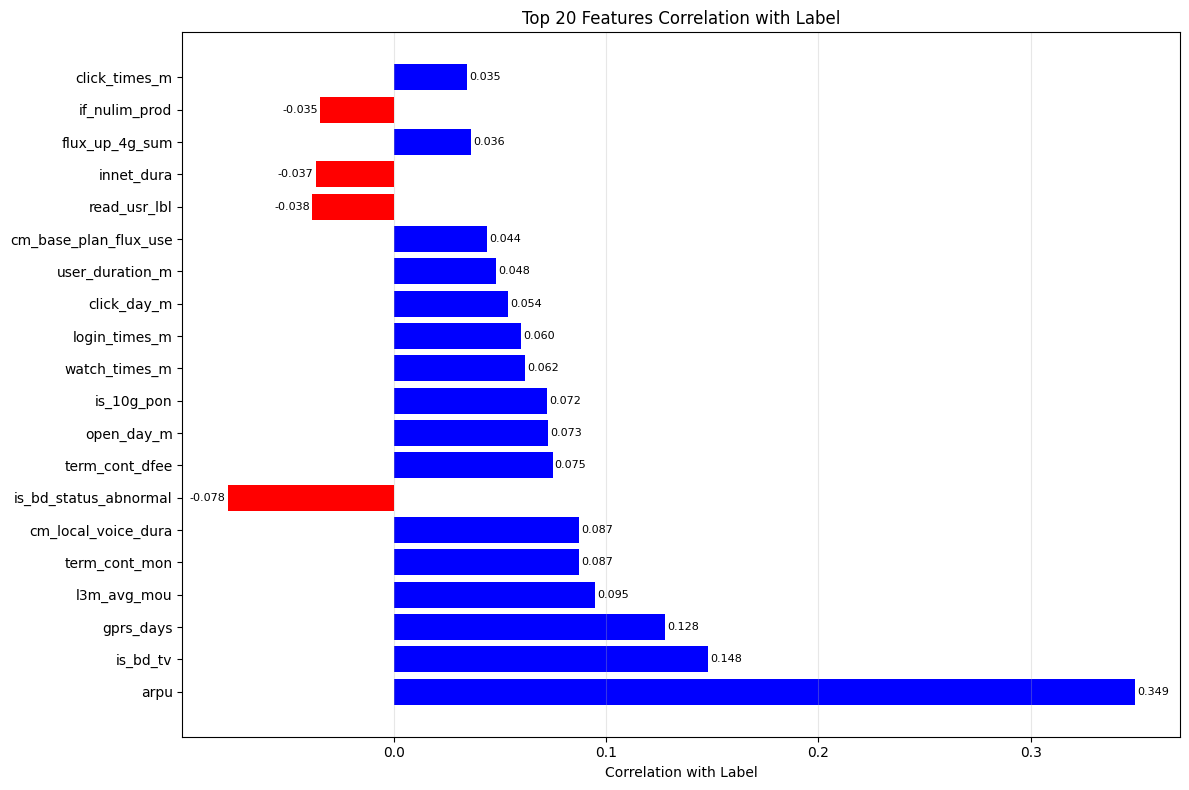

Missing values summary:
long_vid_ngt_use_dur     47451
gm_use_dur               47451
long_vid_dayt_use_dur    47451
long_vid_use_dur         47451
shrt_vid_ngt_use_dur     47451
shrt_vid_dayt_use_dur    47451
shrt_vid_use_dur         47451
sev_vid_usr_lbl          47451
liv_usr_lbl              47451
netdisk_usr_lbl          47451
vid_usr_lbl              47451
read_usr_lbl             47451
netdisk_dayt_use_dur     47451
netdisk_ngt_use_dur      47451
hi_flux_usr_lbl          47451
msc_usr_lbl              47451
gm_usr_lbl               47451
anchor_dayt_use_dur      47451
netdisk_use_dur          47451
wtch_liv_ngt_use_dur     47451
wtch_liv_dayt_use_dur    47451
wtch_liv_use_dur         47451
anchor_ngt_use_dur       47451
gm_ngt_use_dur           47451
gm_dayt_use_dur          47451
anchor_use_dur           47451
dtype: int64

Total samples: 59904
Complete cases: 12453

Top correlations using pairwise complete observations:
arpu                     0.348964
is_bd_tv               

In [5]:
# 2. Visualize top correlations with label
plt.figure(figsize=(12, 8))
top_corr = label_correlations.head(20)
colors = ['red' if x < 0 else 'blue' for x in top_corr.values]
bars = plt.barh(range(len(top_corr)), top_corr.values, color=colors)
plt.yticks(range(len(top_corr)), top_corr.index, fontsize=10)
plt.xlabel('Correlation with Label')
plt.title('Top 20 Features Correlation with Label')
plt.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_corr.values)):
    plt.text(val + 0.001 if val >= 0 else val - 0.001, i, f'{val:.3f}', 
             va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

# 3. Handle missing values and recalculate correlations
print("Missing values summary:")
missing_summary = df[numeric_cols].isnull().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

# Option 1: Use pairwise correlations (handles missing values automatically)
print(f"\nTotal samples: {len(df)}")
print(f"Complete cases: {len(df.dropna())}")

# Calculate pairwise correlations (default behavior)
pairwise_corr = df[numeric_cols].corr()['label'].drop('label').sort_values(key=abs, ascending=False)
print("\nTop correlations using pairwise complete observations:")
print(pairwise_corr.head(15))

/tmp/ipykernel_2212056/1056176214.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(valid_data[col], valid_data[target_col])
/tmp/ipykernel_2212056/1056176214.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(valid_data[col], valid_data[target_col])


Top 15 correlations with statistical info:
                  feature  correlation        p_value  sample_size  \
4                    arpu     0.348964   0.000000e+00        59904   
32               is_bd_tv     0.148115  6.370375e-291        59904   
24              gprs_days     0.127634  5.812284e-216        59904   
5             l3m_avg_mou     0.094834  1.054375e-119        59904   
39          term_cont_mon     0.087319  1.031823e-101        59904   
9     cm_local_voice_dura     0.087294  1.177303e-101        59904   
27  is_bd_status_abnormal    -0.078128   9.501095e-82        59904   
40         term_cont_dfee     0.074877   3.193742e-75        59904   
37             open_day_m     0.072893   2.243082e-71        59904   
28             is_10g_pon     0.072071   8.182242e-70        59904   
36          watch_times_m     0.062024   3.822132e-52        59904   
34          login_times_m     0.060022   6.122605e-49        59904   
38            click_day_m     0.053700   1.6479

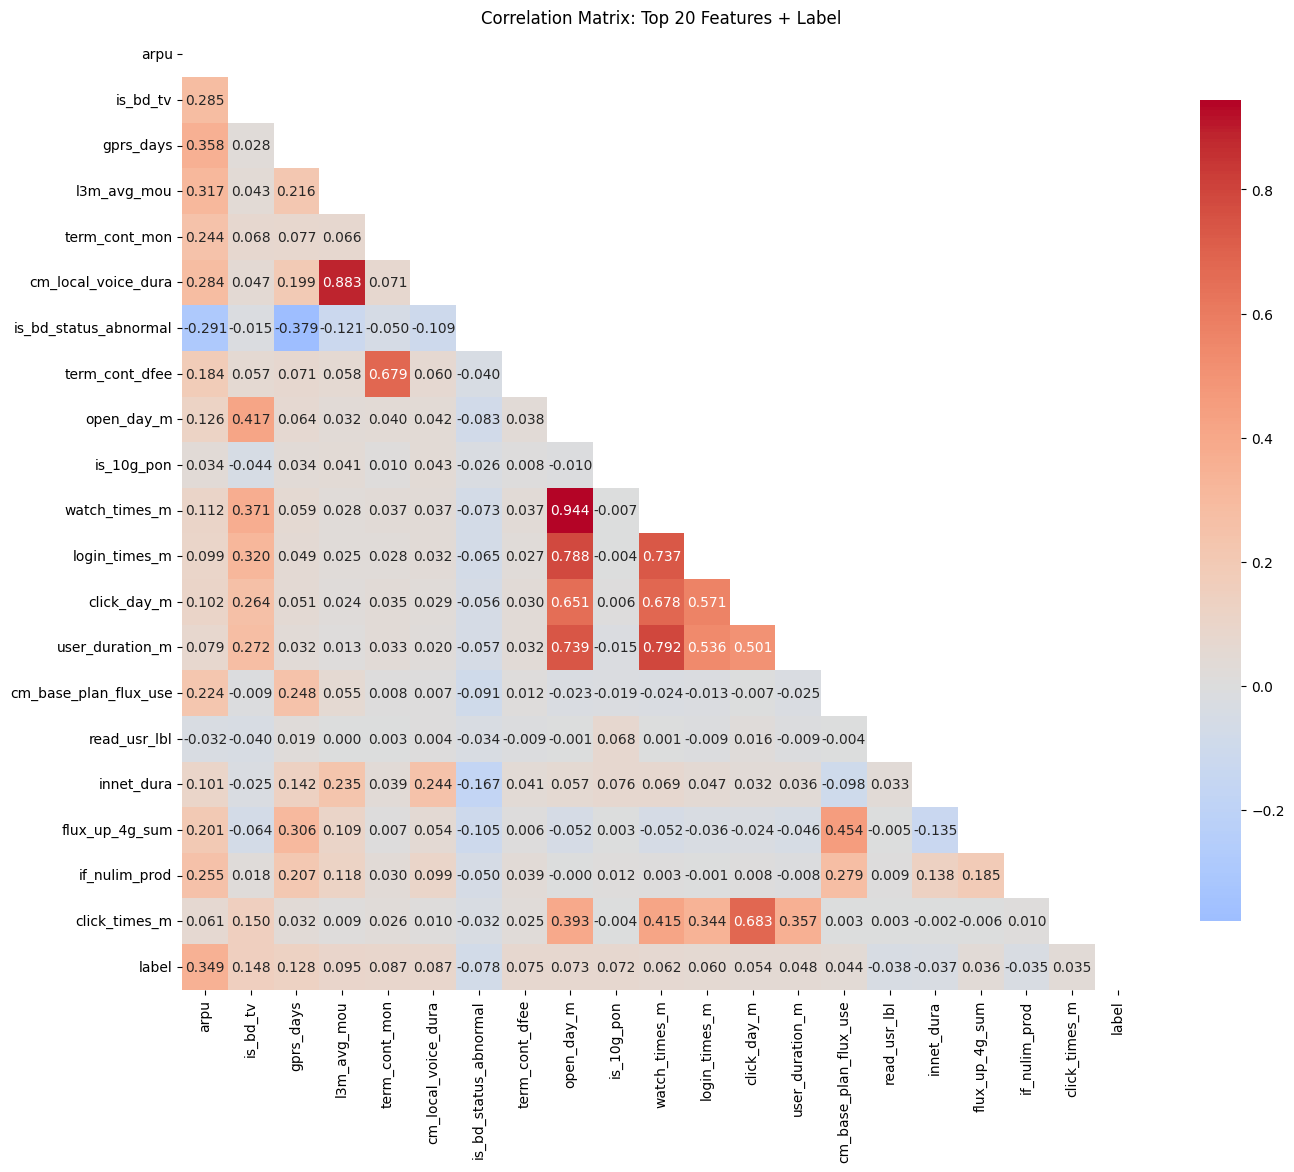

In [6]:
# 4. Statistical significance testing
from scipy.stats import pearsonr

def correlation_with_significance(df, target_col='label'):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    correlations = []
    
    for col in numeric_cols:
        if col != target_col:
            # Get valid pairs (non-missing)
            valid_data = df[[col, target_col]].dropna()
            
            if len(valid_data) > 10:  # Minimum sample size
                try:
                    corr, p_value = pearsonr(valid_data[col], valid_data[target_col])
                    correlations.append({
                        'feature': col,
                        'correlation': corr,
                        'p_value': p_value,
                        'abs_correlation': abs(corr),
                        'sample_size': len(valid_data),
                        'missing_pct': (len(df) - len(valid_data)) / len(df) * 100
                    })
                except:
                    continue
    
    # Convert to DataFrame and sort
    corr_df = pd.DataFrame(correlations)
    corr_df = corr_df.sort_values('abs_correlation', ascending=False)
    
    return corr_df

# Get correlations with significance
corr_results = correlation_with_significance(df)
print("Top 15 correlations with statistical info:")
print(corr_results.head(15)[['feature', 'correlation', 'p_value', 'sample_size', 'missing_pct']])

# Filter for significant correlations
significant_corr = corr_results[corr_results['p_value'] < 0.05]
print(f"\nStatistically significant correlations (p < 0.05): {len(significant_corr)}")
print("\nTop 10 significant correlations:")
print(significant_corr.head(10)[['feature', 'correlation', 'p_value']])

# 5. Visualize correlation heatmap for top features
top_features = corr_results.head(20)['feature'].tolist() + ['label']
subset_corr = df[top_features].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(subset_corr, dtype=bool))  # Mask upper triangle
sns.heatmap(subset_corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix: Top 20 Features + Label')
plt.tight_layout()
plt.show()

Missing data analysis:
Columns with missing data: 26
gm_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
gm_dayt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
gm_ngt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
shrt_vid_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
shrt_vid_dayt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
shrt_vid_ngt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
long_vid_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
long_vid_dayt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
long_vid_ngt_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
anchor_use_dur: Label 0 missing: 79.3%, Label 1 missing: 79.0%
Top 15 features by Random Forest importance:
                feature  importance
4                  arpu    0.121608
3            innet_dura    0.041121
19    cm_base_plan_flux    0.038034
18      cm_flux_tot_cnt    0.037465
29            bd_flux_m    0.032808
5           l3m_avg_mou    0.

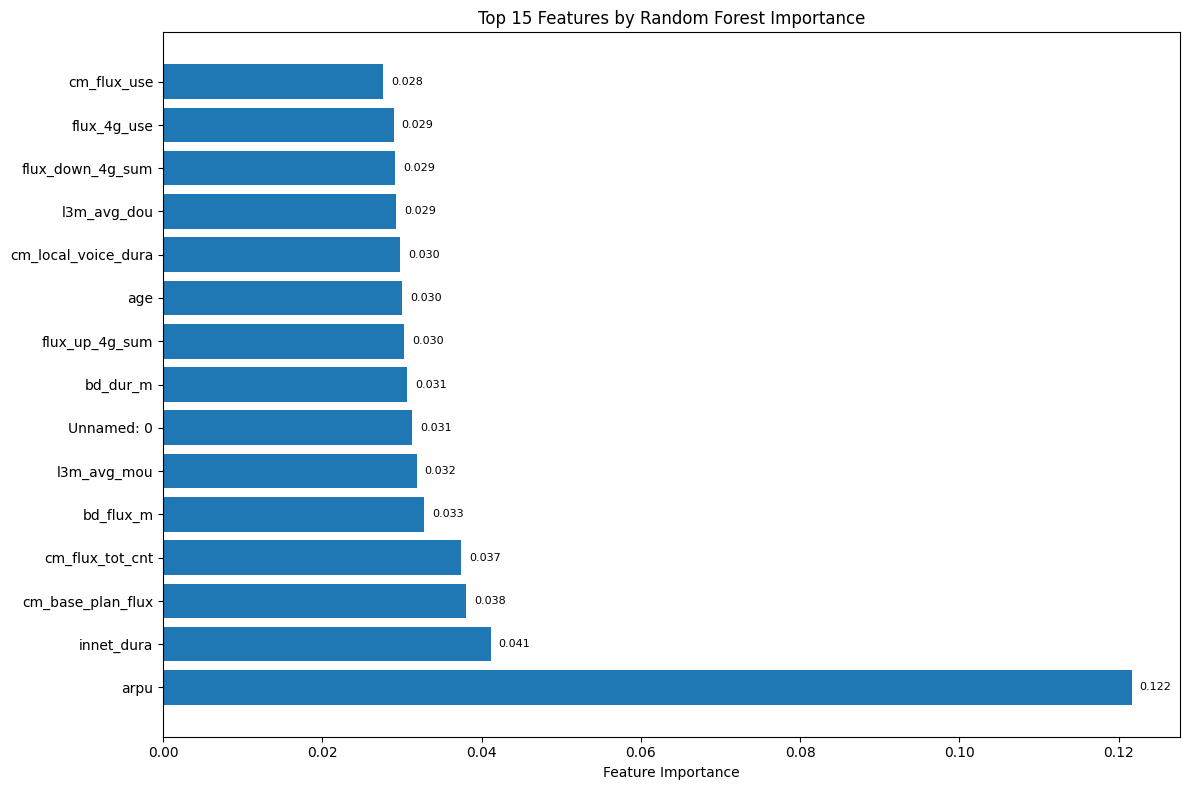


Model Accuracy: 0.797

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.87      8981
           1       0.68      0.36      0.47      3000

    accuracy                           0.80     11981
   macro avg       0.75      0.65      0.67     11981
weighted avg       0.78      0.80      0.77     11981



In [7]:
# 6. Analyze missing data patterns
def analyze_missing_patterns(df):
    missing_cols = df.columns[df.isnull().any()].tolist()
    
    if len(missing_cols) > 0:
        print("Missing data analysis:")
        print(f"Columns with missing data: {len(missing_cols)}")
        
        # Check if missing data is related to label
        for col in missing_cols[:10]:  # Check first 10 missing columns
            missing_mask = df[col].isnull()
            if missing_mask.sum() > 0:
                label_0_missing = missing_mask[df['label'] == 0].mean()
                label_1_missing = missing_mask[df['label'] == 1].mean()
                print(f"{col}: Label 0 missing: {label_0_missing:.1%}, Label 1 missing: {label_1_missing:.1%}")

analyze_missing_patterns(df)

# 7. Feature importance using Random Forest (handles missing values)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare data - fill missing values with median for numeric columns
X = df[numeric_cols].copy()
X = X.drop('label', axis=1)  # Remove target
X_filled = X.fillna(X.median())  # Fill with median
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_filled, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': X_filled.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 features by Random Forest importance:")
print(importance_df.head(15))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_importance = importance_df.head(15)
bars = plt.barh(range(len(top_importance)), top_importance['importance'])
plt.yticks(range(len(top_importance)), top_importance['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features by Random Forest Importance')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_importance['importance'])):
    plt.text(val + 0.001, i, f'{val:.3f}', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()

# Model performance
from sklearn.metrics import classification_report, accuracy_score
y_pred = rf.predict(X_test)
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, f1_score, precision_recall_curve
import matplotlib.pyplot as plt
import pandas as pd

# Custom Dataset
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        if hasattr(y, 'values'):
            y = y.values
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Residual Block with proper dimension handling
class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.25):
        super(ResidualBlock, self).__init__()
        
        self.block = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.LayerNorm(out_features),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(out_features, out_features),
            nn.LayerNorm(out_features),
        )
        
        # Projection for residual if dimensions don't match
        if in_features != out_features:
            self.projection = nn.Linear(in_features, out_features)
        else:
            self.projection = None
    
    def forward(self, x):
        identity = x
        out = self.block(x)
        
        if self.projection is not None:
            identity = self.projection(identity)
        
        out = out + identity
        out = F.gelu(out)
        return out

# Powerful Transformer-style Model
class PowerfulAttentionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=384, num_transformer_layers=3, 
                 num_heads=8, dropout=0.25):
        super(PowerfulAttentionClassifier, self).__init__()
        
        self.input_dim = input_dim
        
        # Input normalization
        self.input_bn = nn.BatchNorm1d(input_dim)
        
        # Learn feature importance
        self.feature_importance = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid()
        )
        
        # Feature embedding
        self.feature_embedding = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        # Transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        
        # Cross-attention
        self.cross_attention = nn.MultiheadAttention(
            hidden_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.cross_norm = nn.LayerNorm(hidden_dim)
        
        # Deep residual blocks with proper dimensions
        self.deep_blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, hidden_dim, dropout),
            ResidualBlock(hidden_dim, hidden_dim // 2, dropout),
            ResidualBlock(hidden_dim // 2, 256, dropout),
            ResidualBlock(256, 128, dropout)
        ])
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )
        
        # Temperature for calibration
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
        
    def forward(self, x):
        # Normalize input
        x_norm = self.input_bn(x)
        
        # Apply learned feature importance
        importance = self.feature_importance(x_norm)
        x_weighted = x_norm * importance
        
        # Embed features
        x_embed = self.feature_embedding(x_weighted)
        x_embed = x_embed.unsqueeze(1)  # (batch, 1, hidden)
        
        # Transformer encoding
        x_trans = self.transformer(x_embed)
        
        # Cross-attention with residual
        x_cross, _ = self.cross_attention(x_trans, x_trans, x_trans)
        x_combined = self.cross_norm(x_trans + x_cross)
        x_combined = x_combined.squeeze(1)  # (batch, hidden)
        
        # Apply residual blocks sequentially
        x = x_combined
        for block in self.deep_blocks:
            x = block(x)
        
        # Classification with temperature scaling
        logits = self.classifier(x)
        logits = logits / self.temperature
        
        return logits, importance

# Focal Loss with hard negative mining
class BalancedFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean', hard_ratio=0.3):
        super(BalancedFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.hard_ratio = hard_ratio
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        # Hard negative mining
        if self.hard_ratio > 0 and self.training:
            num_hard = max(1, int(self.hard_ratio * focal_loss.size(0)))
            hard_loss, _ = torch.topk(focal_loss, num_hard)
            easy_indices = focal_loss < hard_loss.min()
            if easy_indices.sum() > 0:
                easy_loss = focal_loss[easy_indices]
                focal_loss = torch.cat([hard_loss, easy_loss * 0.5])
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss

# Training with adversarial examples
def train_epoch_advanced(model, train_loader, criterion, optimizer, device, epsilon=0.01):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Standard training
        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs, targets)
        
        # Adversarial training (30% of batches)
        if np.random.rand() > 0.7:
            inputs.requires_grad = True
            loss.backward(retain_graph=True)
            
            # Create adversarial perturbation
            if inputs.grad is not None:
                data_grad = inputs.grad.data
                perturbed_data = inputs + epsilon * data_grad.sign()
                perturbed_data = perturbed_data.detach()
                
                # Forward with adversarial examples
                optimizer.zero_grad()
                outputs_adv, _ = model(perturbed_data)
                loss_adv = criterion(outputs_adv, targets)
                
                # Combined loss
                total_loss_batch = 0.7 * loss.detach() + 0.3 * loss_adv
                total_loss_batch.backward()
            else:
                loss.backward()
        else:
            loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    return total_loss / len(train_loader), 100. * correct / total

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs, _ = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    return total_loss / len(val_loader), 100. * correct / total, all_preds, all_targets, all_probs

# Find optimal threshold
def find_optimal_threshold(y_true, y_probs, metric='f1'):
    """Find threshold that optimizes the given metric"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    
    if metric == 'f1':
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
        optimal_idx = np.argmax(f1_scores)
        optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
        return optimal_threshold, f1_scores[optimal_idx]

# Prepare data
print("Preparing data...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

if hasattr(y_train, 'values'):
    y_train_np = y_train.values
else:
    y_train_np = y_train

if hasattr(y_test, 'values'):
    y_test_np = y_test.values
else:
    y_test_np = y_test

# Split training data
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train_np, test_size=0.15, random_state=42, stratify=y_train_np
)

# Create datasets
train_dataset = TabularDataset(X_train_split, y_train_split)
val_dataset = TabularDataset(X_val_split, y_val_split)
test_dataset = TabularDataset(X_test_scaled, y_test_np)

# Calculate class weights
class_counts = np.bincount(y_train_split)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 2
class_weights[1] = class_weights[1] * 2.2  # Boost minority class

print(f"Class distribution in training: {class_counts}")
print(f"Class weights: {class_weights}")

# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

input_dim = X_train_scaled.shape[1]
model = PowerfulAttentionClassifier(
    input_dim=input_dim,
    hidden_dim=384,
    num_transformer_layers=3,
    num_heads=8,
    dropout=0.25
).to(device)

print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss function
alpha = torch.FloatTensor(class_weights).to(device)
criterion = BalancedFocalLoss(alpha=alpha, gamma=2.0, hard_ratio=0.3)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0003, weight_decay=0.0005)

# Scheduler with warmup
from torch.optim.lr_scheduler import LambdaLR
def lr_lambda(epoch):
    warmup_epochs = 5
    max_epochs = 120
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (max_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

# Training loop
num_epochs = 120
best_val_f1_minority = 0
patience = 30
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("\nStarting training...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch_advanced(
        model, train_loader, criterion, optimizer, device, epsilon=0.01
    )
    val_loss, val_acc, val_preds, val_targets, val_probs = validate(
        model, val_loader, criterion, device
    )
    
    # Calculate metrics
    val_f1_minority = f1_score(val_targets, val_preds, pos_label=1)
    
    # Find optimal threshold
    optimal_threshold, optimal_f1 = find_optimal_threshold(val_targets, val_probs, metric='f1')
    val_preds_optimal = (np.array(val_probs) >= optimal_threshold).astype(int)
    val_f1_optimal = f1_score(val_targets, val_preds_optimal, pos_label=1)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step()
    
    if (epoch + 1) % 5 == 0 or epoch < 10:
        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | '
              f'Val Acc: {val_acc:.2f}%, F1-Min: {val_f1_minority:.4f}, '
              f'F1-Opt: {val_f1_optimal:.4f} (th={optimal_threshold:.3f})')
    
    # Save best model
    if val_f1_optimal > best_val_f1_minority:
        best_val_f1_minority = val_f1_optimal
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimal_threshold': optimal_threshold,
            'epoch': epoch
        }, 'best_powerful_model.pth')
        if (epoch + 1) % 5 == 0 or epoch < 10:
            print(f'  --> Saved best model (F1: {val_f1_optimal:.4f}, Threshold: {optimal_threshold:.3f})')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break


Preparing data...
Class distribution in training: [30534 10200]
Class weights: [0.50081013 3.29821771]
Using device: cuda

Total parameters: 6,697,193

Starting training...


/home/mzhyui/git/diffuser_test/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch [1/120] Train Loss: 0.1662, Train Acc: 25.72% | Val Acc: 25.04%, F1-Min: 0.4005, F1-Opt: 0.5416 (th=0.793)
  --> Saved best model (F1: 0.5416, Threshold: 0.793)
Epoch [2/120] Train Loss: 0.1445, Train Acc: 25.84% | Val Acc: 25.04%, F1-Min: 0.4005, F1-Opt: 0.5532 (th=0.791)
  --> Saved best model (F1: 0.5532, Threshold: 0.791)
Epoch [3/120] Train Loss: 0.1422, Train Acc: 25.48% | Val Acc: 25.04%, F1-Min: 0.4005, F1-Opt: 0.5599 (th=0.780)
  --> Saved best model (F1: 0.5599, Threshold: 0.780)
Epoch [4/120] Train Loss: 0.1401, Train Acc: 26.53% | Val Acc: 25.04%, F1-Min: 0.4005, F1-Opt: 0.5641 (th=0.782)
  --> Saved best model (F1: 0.5641, Threshold: 0.782)
Epoch [5/120] Train Loss: 0.1392, Train Acc: 28.79% | Val Acc: 25.04%, F1-Min: 0.4005, F1-Opt: 0.5642 (th=0.791)
  --> Saved best model (F1: 0.5642, Threshold: 0.791)
Epoch [6/120] Train Loss: 0.1380, Train Acc: 29.17% | Val Acc: 39.18%, F1-Min: 0.4491, F1-Opt: 0.5628 (th=0.783)
Epoch [7/120] Train Loss: 0.1371, Train Acc: 29.50% 

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 


Using optimal threshold: 0.7874

FINAL EVALUATION ON TEST SET

RESULTS WITH DEFAULT THRESHOLD (0.5)
Test Accuracy: 36.34%

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.15      0.27      8981
     Class 1       0.28      0.99      0.44      3000

    accuracy                           0.36     11981
   macro avg       0.63      0.57      0.35     11981
weighted avg       0.81      0.36      0.31     11981


RESULTS WITH OPTIMAL THRESHOLD (0.7874)
Test Accuracy: 72.89%

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.88      0.73      0.80      8981
     Class 1       0.47      0.71      0.57      3000

    accuracy                           0.73     11981
   macro avg       0.68      0.72      0.69     11981
weighted avg       0.78      0.73      0.74     11981


ROC-AUC Score: 0.7929

Confusion Matrix (Default):
[[1377 7604]
 [  23 2977]]

Confusion Matrix (Optimal):
[[65

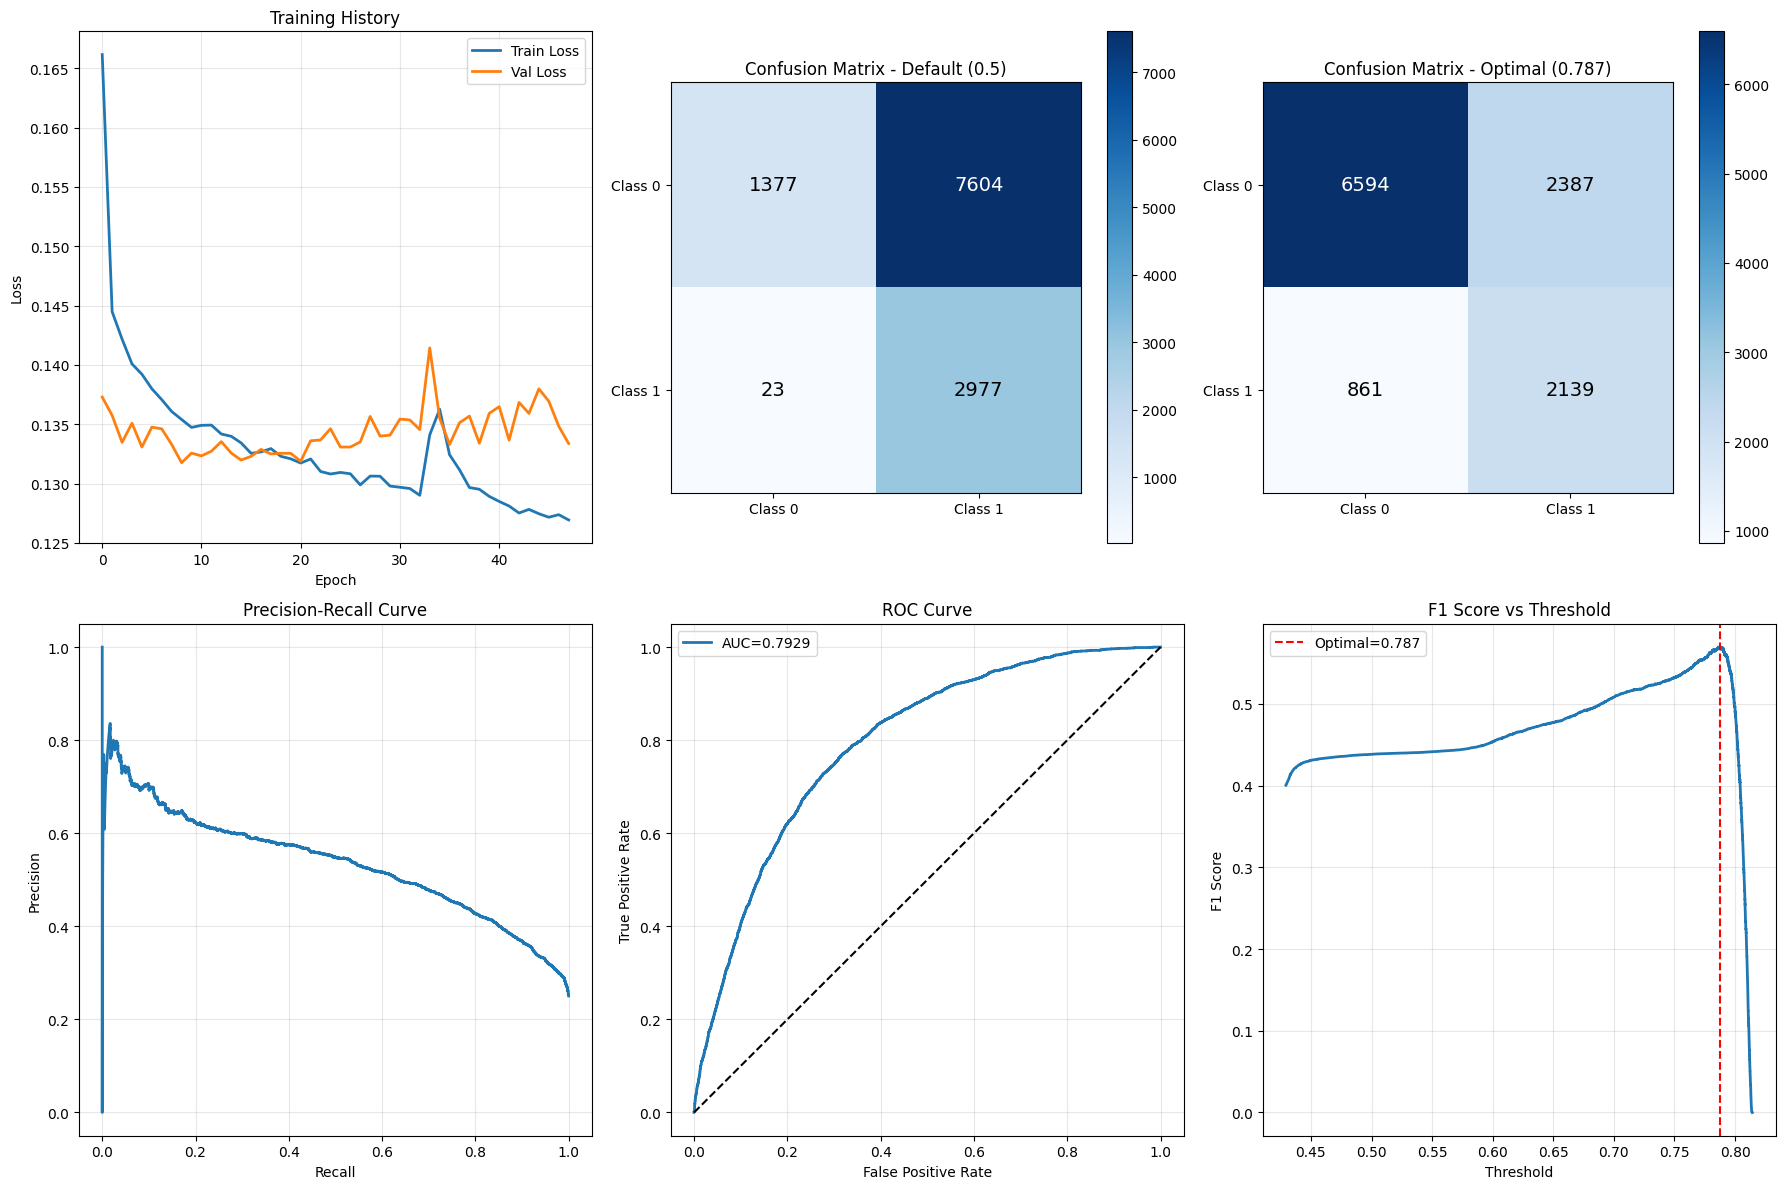


FEATURE IMPORTANCE

Top 20 features:
                  feature  importance
4                    arpu    0.610141
58     if_like_games_cust    0.535114
23      cm_over_plan_flux    0.529998
57     if_high_games_cust    0.524509
46            read_time_m    0.518752
52           travel_cnt_m    0.512829
72       wtch_liv_use_dur    0.512778
22  cm_chos_plan_flux_use    0.510924
18        cm_flux_tot_cnt    0.508712
7       l3m_avg_bill_dura    0.506712
32               is_bd_tv    0.506498
5             l3m_avg_mou    0.503434
61        gm_dayt_use_dur    0.500946
54             edu_time_m    0.500812
27  is_bd_status_abnormal    0.500352
48            music_cnt_m    0.499377
3              innet_dura    0.499201
51          travel_time_m    0.498195
29              bd_flux_m    0.497627
56         fashion_time_m    0.497615

FINAL COMPARISON

         Metric Random Forest  Powerful Attention
      Accuracy         0.797            0.728904
Precision (C0)          0.82            0.8845

In [11]:

# Load best model
checkpoint = torch.load('best_powerful_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
optimal_threshold = checkpoint['optimal_threshold']

print(f"\nUsing optimal threshold: {optimal_threshold:.4f}")

# Evaluate on test set
print("\n" + "="*70)
print("FINAL EVALUATION ON TEST SET")
print("="*70)

test_loss, test_acc, y_pred_default, y_true, y_probs = validate(
    model, test_loader, criterion, device
)

# Apply optimal threshold
y_pred_optimal = (np.array(y_probs) >= optimal_threshold).astype(int)

print(f"\n{'='*70}")
print("RESULTS WITH DEFAULT THRESHOLD (0.5)")
print(f"{'='*70}")
print(f"Test Accuracy: {accuracy_score(y_true, y_pred_default)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred_default, target_names=['Class 0', 'Class 1']))

print(f"\n{'='*70}")
print(f"RESULTS WITH OPTIMAL THRESHOLD ({optimal_threshold:.4f})")
print(f"{'='*70}")
print(f"Test Accuracy: {accuracy_score(y_true, y_pred_optimal)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred_optimal, target_names=['Class 0', 'Class 1']))

# ROC-AUC
roc_auc = roc_auc_score(y_true, y_probs)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Confusion matrices
cm_default = confusion_matrix(y_true, y_pred_default)
cm_optimal = confusion_matrix(y_true, y_pred_optimal)

print("\nConfusion Matrix (Default):")
print(cm_default)
print("\nConfusion Matrix (Optimal):")
print(cm_optimal)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Training history
axes[0, 0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training History')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Confusion matrices
for idx, (cm, title) in enumerate([(cm_default, 'Default (0.5)'), 
                                     (cm_optimal, f'Optimal ({optimal_threshold:.3f})')]):
    ax = axes[0, idx+1]
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'Confusion Matrix - {title}')
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.set_yticklabels(['Class 0', 'Class 1'])
    
    thresh = cm.max() / 2.
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black", fontsize=14)

# Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
axes[1, 0].plot(recalls, precisions, linewidth=2)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].grid(True, alpha=0.3)

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
axes[1, 1].plot(fpr, tpr, linewidth=2, label=f'AUC={roc_auc:.4f}')
axes[1, 1].plot([0, 1], [0, 1], 'k--')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# F1 vs Threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
axes[1, 2].plot(thresholds, f1_scores[:-1], linewidth=2)
axes[1, 2].axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal={optimal_threshold:.3f}')
axes[1, 2].set_xlabel('Threshold')
axes[1, 2].set_ylabel('F1 Score')
axes[1, 2].set_title('F1 Score vs Threshold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance
print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)

model.eval()
importance_list = []

with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        _, importance = model(inputs)
        importance_list.append(importance.cpu().numpy())

all_importance = np.concatenate(importance_list, axis=0)
avg_importance = all_importance.mean(axis=0)

feature_importance_df = pd.DataFrame({
    'feature': X_filled.columns,
    'importance': avg_importance
}).sort_values('importance', ascending=False)

print("\nTop 20 features:")
print(feature_importance_df.head(20))

# Final comparison
print("\n" + "="*70)
print("FINAL COMPARISON")
print("="*70)

from sklearn.metrics import precision_recall_fscore_support

precision_opt, recall_opt, f1_opt, _ = precision_recall_fscore_support(
    y_true, y_pred_optimal, average=None
)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (C0)', 'Precision (C1)', 
               'Recall (C0)', 'Recall (C1)', 'F1 (C0)', 'F1 (C1)', 'ROC-AUC'],
    'Random Forest': [0.797, 0.82, 0.68, 0.94, 0.36, 0.87, 0.47, '-'],
    'Powerful Attention': [accuracy_score(y_true, y_pred_optimal),
                          precision_opt[0], precision_opt[1],
                          recall_opt[0], recall_opt[1],
                          f1_opt[0], f1_opt[1], roc_auc]
})

print("\n", comparison_df.to_string(index=False))

print("\n" + "="*70)
improvement_f1 = ((f1_opt[1]/0.47 - 1) * 100)
improvement_precision = ((precision_opt[1]/0.68 - 1) * 100)
print(f"  ✓ F1 on Class 1: 0.47 → {f1_opt[1]:.3f} ({improvement_f1:+.1f}%)")
print(f"  ✓ Precision on Class 1: 0.68 → {precision_opt[1]:.3f} ({improvement_precision:+.1f}%)")
print(f"  ✓ Recall on Class 1: 0.36 → {recall_opt[1]:.3f}")
print(f"  ✓ ROC-AUC: {roc_auc:.4f}")
print(f"  ✓ Optimal Threshold: {optimal_threshold:.4f}")